In this notebook, we’ll demonstrate how to design photonic components that remain robust against manufacturing variations—represented by perturbations in the optimizable design parameters—using the Sharpness‑Aware Minimization (SAM) optimizer.

Standard optimization methods often converge to parameter values that yield low loss but reside in "sharp" minima in the loss landscape; such solutions can be highly sensitive to small perturbations and may not perform well when fabricated. Inspired by the connection between the geometry of the loss landscape and generalization, SAM seeks parameter values that lie in "flat" regions, corresponding to neighborhoods with uniformly low loss. Originally developed to improve generalization in machine learning models, SAM achieves this by minimizing both the loss value and the loss sharpness simultaneously. This inherent robustness to perturbations makes SAM suited for designing photonic devices that are tolerant to manufacturing errors, such as geometry variations in lithography.   

We will apply SAM to design a robust 50/50 directional coupler (DC), optimizing the boundaries of the coupling region defined using PolySlab structures within Tidy3D. This approach aims to produce a DC design whose performance is stable across a range of likely manufacturing variations in coupling region boundaries, drawing on the principles outlined by Foret, P., Kleiner, A., Mobahi, H. and Neyshabur, B., 2020. Sharpness-aware minimization for efficiently improving generalization. arXiv preprint arXiv:2010.01412.

We start by importing necessary packages: autograd and optax for optimization (including the SAM optimizer from optax.contrib), tidy3d for simulation and its autograd features (interpolate_spline), and gdstk for geometry definition.

In [ ]:
import copy
import pickle

import autograd.numpy as np
import gdstk
import matplotlib.pyplot as plt
import optax
import tidy3d as td
from autograd import value_and_grad
from optax import contrib
from tidy3d import web
from tidy3d.plugins.autograd import interpolate_spline

rng_seed = 100

Next, we define the basic geometric parameters for the directional coupler, including the nominal waveguide width, dimensions for the input/output S-bends, the length and base gap of the central coupling region to be optimized, and the spline discretization step.

In [ ]:
w_si_nom = 0.3  # nominal silicon waveguide width (used for outer wall calculation)
input_wg_len = 10.0  # Length of the straight input waveguide sections
bend_length = 15  # Length of the S-bend transition region
wg_spacing_in = 5  # Spacing between the two waveguides centerlines
coup_length = 11  # Coupler length (optimization region)
coup_gap_base = 0.12  # Base gap between inner edges of the coupler waveguides
dx = 0.01  # Spline discretization step for generating points

The geometry of the coupler waveguides is defined by vertices calculated from spline control points. The functions below take arrays of y-offset values (dy_..._spline_pts) as input, use cubic spline interpolation (sidewall_from_spline) to create smooth inner and outer walls (inner_wall, outer_wall), and combine these to form the vertices for the top and bottom waveguides (coupler_wg_vertices).

In [ ]:
def sidewall_from_spline(dy_spline_pts: np.ndarray, y_base: float, coup_length: float, dx: float):
    """Generates sidewall (x,y) points from spline offsets relative to a base y."""
    _dy_spline_pts = np.concatenate([[0.0], dy_spline_pts, [0.0]])
    npoints = int(coup_length / dx)
    x_knots = np.linspace(0, 1, len(_dy_spline_pts))
    dy_v_x = interpolate_spline(
        x_knots, _dy_spline_pts, num_points=npoints, endpoint_derivatives=(0, 0), order=3
    )
    y = y_base + dy_v_x
    x = np.linspace(-coup_length / 2, coup_length / 2, npoints)
    return x, y


def inner_wall(
    dy_inner_spline_pts: np.ndarray, coup_gap_base: float, coup_length: float, dx: float
):
    """Calculates coordinates for the inner wall of one coupler arm."""
    return sidewall_from_spline(dy_inner_spline_pts, coup_gap_base / 2, coup_length, dx)


def outer_wall(
    dy_outer_spline_pts: np.ndarray,
    coup_gap_base: float,
    w_si_nom: float,
    coup_length: float,
    dx: float,
):
    """Calculates coordinates for the outer wall of one coupler arm."""
    return sidewall_from_spline(dy_outer_spline_pts, coup_gap_base / 2 + w_si_nom, coup_length, dx)


def coupler_wg(
    dy_top_inner_spline_pts: np.ndarray,
    dy_top_outer_spline_pts: np.ndarray,
    dy_bot_inner_spline_pts: np.ndarray,
    dy_bot_outer_spline_pts: np.ndarray,
    dw_si: float,
) -> tuple[td.PolySlab, td.PolySlab]:
    """Generates the vertices for the top and bottom coupler waveguides."""
    # Calculate vertices for the top waveguide
    x_top_inner, y_top_inner = inner_wall(dy_top_inner_spline_pts, coup_gap_base, coup_length, dx)
    x_top_outer, y_top_outer = outer_wall(
        dy_top_outer_spline_pts, coup_gap_base, w_si_nom, coup_length, dx
    )
    vertices_top = np.concatenate(
        [
            np.column_stack((x_top_inner, y_top_inner)),
            np.column_stack((x_top_outer[::-1], y_top_outer[::-1])),
        ]
    )

    # Calculate vertices for the bottom waveguide (mirrored top)
    x_bot_inner, y_bot_inner = inner_wall(dy_bot_inner_spline_pts, coup_gap_base, coup_length, dx)
    x_bot_outer, y_bot_outer = outer_wall(
        dy_bot_outer_spline_pts, coup_gap_base, w_si_nom, coup_length, dx
    )
    vertices_bot = np.concatenate(
        [
            np.column_stack((x_bot_inner, -y_bot_inner)),
            np.column_stack((x_bot_outer[::-1], -y_bot_outer[::-1])),
        ]
    )
    top_geometry = td.PolySlab(
        vertices=vertices_top, axis=2, slab_bounds=(-td.inf, +td.inf), dilation=dw_si / 2.0
    )
    bot_geometry = td.PolySlab(
        vertices=vertices_bot, axis=2, slab_bounds=(-td.inf, +td.inf), dilation=dw_si / 2.0
    )
    return top_geometry, bot_geometry

Let's define a simple starting case (straight waveguides using zero spline offsets) and plot the resulting vertices to check the geometry of the coupling region.

Text(0, 0.5, 'Y coordinate (um)')

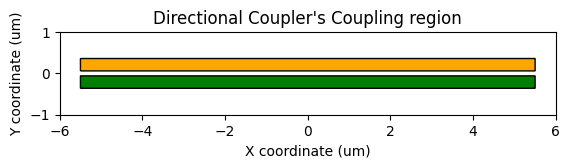

In [ ]:
num_spline_pts = 100  # Number of spline control points
dy_top_inner_spline_pts = np.zeros(num_spline_pts)
dy_top_outer_spline_pts = np.zeros(num_spline_pts)
dy_bot_inner_spline_pts = np.zeros(num_spline_pts)
dy_bot_outer_spline_pts = np.zeros(num_spline_pts)


top_coupler_geo, bot_coupler_geo = coupler_wg(
    dy_top_inner_spline_pts,
    dy_top_outer_spline_pts,
    dy_bot_inner_spline_pts,
    dy_bot_outer_spline_pts,
    dw_si=0.0,
)

f, ax = plt.subplots()
top_coupler_geo.plot(z=0, ax=ax, facecolor="orange")
bot_coupler_geo.plot(z=0, ax=ax, facecolor="g")
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 1)
plt.title("Directional Coupler's Coupling region")
ax.set_xlabel("X coordinate (um)")
ax.set_ylabel("Y coordinate (um)")

This function defines the geometry for the S-shaped bends that connect the input/output waveguides to the central coupling region of the directional coupler.

In [ ]:
def make_sbend(dw_si: float) -> td.Structure:
    """Creates the sbend (with input waveguide) using gdstk."""
    w_in = w_si_nom + dw_si

    cell = gdstk.Cell("sbend")
    # Define one quadrant path
    coup = gdstk.RobustPath(
        (-input_wg_len - bend_length - coup_length / 2, wg_spacing_in / 2),
        w_in,
        layer=0,
        tolerance=1e-3,
    )
    coup.segment((-bend_length - coup_length / 2, wg_spacing_in / 2))
    A = (wg_spacing_in - coup_gap_base - w_in) / 4
    coup.segment(
        (-coup_length / 2 - dw_si / 2, wg_spacing_in / 2 - dw_si / 2),
        offset=lambda u: A * np.cos(np.pi * u) - A,
    )
    cell.add(coup)
    # Add mirrored copies to complete the S-bend geometry
    cell.add(coup.copy().mirror((0, 0), (1, 0)))
    cell.add(coup.copy().mirror((0, 0), (0, 1)))
    cell.add(coup.copy().mirror((0, 0), (1, 0)).mirror((0, 0), (0, 1)))

    sbend_geo = td.PolySlab.from_gds(
        cell,
        gds_layer=0,
        axis=2,
        slab_bounds=(-td.inf, +td.inf),
        sidewall_angle=0,
    )
    return sbend_geo

Lets plot the complete DC.

Text(0.5, 1.0, 'Directional Coupler with S-Bend Geometry')

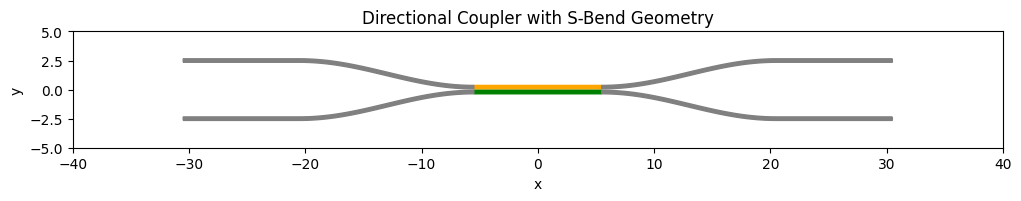

In [ ]:
sbend_geo_list = make_sbend(dw_si=0.0)

f, ax = plt.subplots(figsize=(12, 6))

top_coupler_geo.plot(z=0, ax=ax, facecolor="orange", edgecolor="orange", label="Coupler Top")
bot_coupler_geo.plot(z=0, ax=ax, facecolor="green", edgecolor="green", label="Coupler Bottom")
for poly_slab in sbend_geo_list:
    poly_slab.plot(z=0, ax=ax, facecolor="gray", edgecolor="gray")
ax.set_xlim(-40, 40)
ax.set_ylim(-5, 5)
ax.set_title("Directional Coupler with S-Bend Geometry")

Now we define simulation parameters.

In [7]:
wavelength = 1.31
n_si = 3.5
n_sio2 = 1.45
si_medium = td.Medium(permittivity=n_si**2)
sio2_medium = td.Medium(permittivity=n_sio2**2)

In [ ]:
def make_structures(
    design: dict[str, np.ndarray], dw_si: float
) -> tuple[td.Structure, td.Structure, td.Structure]:
    """Creates the structures for the simulation."""
    sbend_geo = make_sbend(dw_si)
    sbends = td.Structure(geometry=td.GeometryGroup(geometries=sbend_geo), medium=si_medium)
    top_geo, bot_geo = coupler_wg(
        design["dy_top_inner_spline_pts"],
        design["dy_top_outer_spline_pts"],
        design["dy_bot_inner_spline_pts"],
        design["dy_bot_outer_spline_pts"],
        dw_si,
    )
    topwg = td.Structure(geometry=top_geo, medium=si_medium)
    botwg = td.Structure(geometry=bot_geo, medium=si_medium)
    return sbends, topwg, botwg

These functions define the `ModeSource` and `ModeMonitor` objects ('thru'/'cross' for power split measurement). They then assemble the final 2D td.Simulation object using these components, input 2D structures, and appropriate domain, grid, medium, and boundary settings. 

Because our directional coupler can be asymmetric, we perform two separate simulations (one with the source on `port1` and one on `port2`).  This lets us capture any differences in coupling behavior depending on which waveguide is driven, and ensures that our final split‐error metric reflects performance in both input directions.  


In [ ]:
def make_sources_monitors(
    src_x: float,
    mon_x: float,
    src_mon_size: float = 3.0,
    port: str = "port1",
    dw_si: float = 0.0,
    wavelength: float = 1.31,
    src_bandwidth: float = 0.1,
    eval_bandwidth: float = 5e-3,
    eval_num_freqs: int = 1,
) -> tuple[td.ModeSource, list[td.ModeMonitor]]:
    """Creates the source and monitor objects for the simulation."""
    # Calculate the source frequency and bandwidth
    freq0 = td.C_0 / wavelength
    src_bw = freq0 * src_bandwidth / wavelength
    if eval_num_freqs == 1:
        eval_wavelengths = np.array([wavelength])
    else:
        half_bw = eval_bandwidth / 2
        eval_wavelengths = np.linspace(wavelength - half_bw, wavelength + half_bw, eval_num_freqs)
    eval_freqs = td.C_0 / eval_wavelengths
    w_si = w_si_nom + dw_si
    mode_spec_2d = td.ModeSpec(num_modes=1, target_neff=n_si, filter_pol="tm")
    # Create the source and monitor objects
    if port == "port1":
        y_src = -wg_spacing_in / 2
    elif port == "port2":
        y_src = wg_spacing_in / 2

    mode_source = td.ModeSource(
        center=(src_x, y_src, 0.0),
        size=(0.0, w_si + src_mon_size, td.inf),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=src_bw),
        direction="+",
        mode_spec=mode_spec_2d,
        mode_index=0,
    )
    mon_thru = td.ModeMonitor(
        center=(mon_x, y_src, 0.0),
        size=(0.0, w_si + src_mon_size, td.inf),
        freqs=eval_freqs,
        mode_spec=mode_spec_2d,
        name="thru",
    )
    mon_cross = mon_thru.updated_copy(center=(mon_x, -y_src, 0.0), name="cross")
    monitors = [mon_thru, mon_cross]
    return mode_source, monitors


def make_simulation(
    design: dict[str, np.ndarray],
    port: str = "port1",
    dw_si: float = 0.0,
    wavelength=1.31,
    min_steps_per_wvl: float = 30,
    run_time: float = 2e-12,
    eval_bandwidth: float = 5e-3,
    eval_num_freqs: int = 1,
    src_bandwidth: float = 0.1,
) -> td.Simulation:
    """Builds a tidy3d simulation in 2d from the provided design."""

    sbends, topwg, botwg = make_structures(design, dw_si=dw_si)

    # add sources and monitors
    sbnd_geom_bounds = sbends.geometry.bounds
    buf = wavelength
    in_len = input_wg_len
    src_x = sbnd_geom_bounds[0][0] + in_len - buf / 2
    mon_x = sbnd_geom_bounds[1][0] - in_len + buf / 2
    mode_source, monitors = make_sources_monitors(
        src_x,
        mon_x,
        port=port,
        dw_si=dw_si,
        wavelength=wavelength,
        src_bandwidth=src_bandwidth,
        eval_bandwidth=eval_bandwidth,
        eval_num_freqs=eval_num_freqs,
    )

    # Create the simulation box
    sim_box = td.Box.from_bounds(
        rmin=(sbnd_geom_bounds[0][0] + in_len - buf, sbnd_geom_bounds[0][1] - 2, 0.0),
        rmax=(sbnd_geom_bounds[1][0] - in_len + buf, sbnd_geom_bounds[1][1] + 2, 0.0),
    )
    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.PML(), plus=td.PML()),
        y=td.Boundary(minus=td.PML(), plus=td.PML()),
        z=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
    )
    # Create the simulation object
    sim = td.Simulation(
        center=sim_box.center,
        size=(sim_box.size[0], sim_box.size[1], 0.0),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=wavelength),
        structures=[sbends, topwg, botwg],
        sources=[mode_source],
        monitors=monitors,
        run_time=run_time,
        medium=sio2_medium,
        boundary_spec=boundary_spec,
    )

    return sim

Some helper functions for converting design dictionary to/from array.

In [ ]:
def design_to_array(design: dict[str, np.ndarray]) -> tuple[np.ndarray, tuple[int]]:
    """Converts the design dictionary to an array and returns it with lengths."""
    dy_top_inner_spline_pts = design["dy_top_inner_spline_pts"]
    dy_top_outer_spline_pts = design["dy_top_outer_spline_pts"]
    dy_bot_inner_spline_pts = design["dy_bot_inner_spline_pts"]
    dy_bot_outer_spline_pts = design["dy_bot_outer_spline_pts"]
    array = np.hstack(
        [
            dy_top_inner_spline_pts,
            dy_top_outer_spline_pts,
            dy_bot_inner_spline_pts,
            dy_bot_outer_spline_pts,
        ]
    )
    lengths = [
        len(dy_top_inner_spline_pts),
        len(dy_top_outer_spline_pts),
        len(dy_bot_inner_spline_pts),
        len(dy_bot_outer_spline_pts),
    ]
    return array, tuple(lengths)


def array_to_design(array: np.ndarray, lengths: tuple[int]) -> dict[str, np.ndarray]:
    """Converts the array back to the design dictionary."""
    idx = 0
    design = {}
    design["dy_top_inner_spline_pts"] = array[idx : idx + lengths[0]]
    idx += lengths[0]
    design["dy_top_outer_spline_pts"] = array[idx : idx + lengths[1]]
    idx += lengths[1]
    design["dy_bot_inner_spline_pts"] = array[idx : idx + lengths[2]]
    idx += lengths[2]
    design["dy_bot_outer_spline_pts"] = array[idx : idx + lengths[3]]
    return design

Check helper functions.

In [ ]:
# consistency check
orig_design = {
    "dy_top_inner_spline_pts": np.random.rand(num_spline_pts),
    "dy_top_outer_spline_pts": np.random.rand(num_spline_pts),
    "dy_bot_inner_spline_pts": np.random.rand(num_spline_pts),
    "dy_bot_outer_spline_pts": np.random.rand(num_spline_pts),
}

# convert to flat array and back
arr, lengths = design_to_array(orig_design)
recovered = array_to_design(arr, lengths)

# assert that every entry matches
for key in orig_design:
    assert np.allclose(orig_design[key], recovered[key]), f"Mismatch in {key}"
print(" design_to_array - array_to_design check passed")

 design_to_array - array_to_design check passed


Lets plot the sources and monitors in the simulation setup.

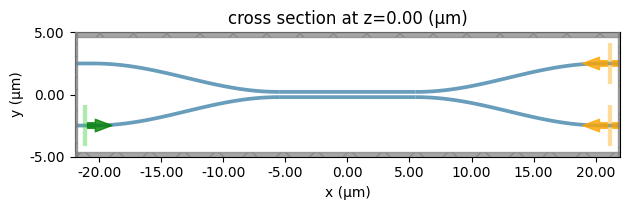

In [ ]:
array = np.zeros(4 * num_spline_pts)
lengths = (num_spline_pts, num_spline_pts, num_spline_pts, num_spline_pts)
design = array_to_design(array, lengths)
sims_port1 = {"nominal": make_simulation(design, port="port1", dw_si=0.0)}
ax = sims_port1["nominal"].plot(z=0)

We will now plot the fields for the initial design where source is at port 1.

Output()

18:26:51 EDT Started working on Batch containing 1 tasks.

18:26:52 EDT Maximum FlexCredit cost: 0.057 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

18:26:53 EDT Batch complete.

Output()

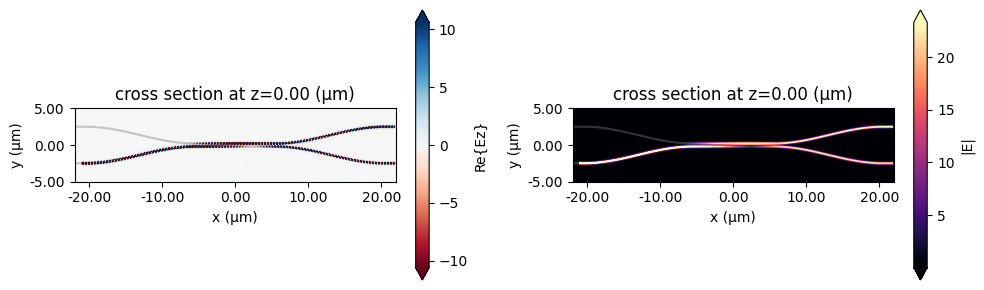

In [ ]:
field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[td.C_0 / wavelength],
    name="field",
)
sims_port1["nominal"] = sims_port1["nominal"].copy(
    update={"monitors": sims_port1["nominal"].monitors + (field_monitor,)}
)
sim_data_initial = web.run_async(sims_port1)
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
sim_data_initial["nominal"].plot_field(
    field_monitor_name="field", field_name="Ez", val="real", ax=ax1
)
sim_data_initial["nominal"].plot_field(
    field_monitor_name="field", field_name="E", val="abs", ax=ax2
)
plt.show()

The objective quantifies how far the directional coupler's performance is from an ideal 50/50 power split at the nominal operating frequency.
We have two simulations for two ports, as the structure may not be symmetric. By simulating with different input ports, we can evaluate the performance of the directional coupler for both propagation directions.

In [ ]:
def compute_split(
    params: np.ndarray, param_lengths: list[int], local_gradient: bool = True, verbose: bool = False
) -> float:
    """
    Given a single-frequency, single-corner setup, build and run
    two sims (thru & cross) and return the 50/50 split error.
    """
    # Build the thru & cross simulations and launch the batch run
    design = array_to_design(params, param_lengths)
    sim_port1 = make_simulation(design, port="port1")
    sim_port2 = make_simulation(design, port="port2")
    batch = web.run_async(
        {"port1": sim_port1, "port2": sim_port2}, local_gradient=local_gradient, verbose=verbose
    )

    # Extract fields for port1 and compute its split‐ratio error
    amp_thru_p1 = batch["port1"]["thru"].amps.sel(mode_index=0, direction="+").data.item()
    amp_cross_p1 = batch["port1"]["cross"].amps.sel(mode_index=0, direction="+").data.item()
    power_thru_p1 = abs(amp_thru_p1) ** 2
    power_cross_p1 = abs(amp_cross_p1) ** 2
    split_error_port1 = (power_thru_p1 - 0.5) ** 2 + (power_cross_p1 - 0.5) ** 2

    # Extract fields for port2 and compute its split‐ratio error, then average
    amp_thru_p2 = batch["port2"]["thru"].amps.sel(mode_index=0, direction="+").data.item()
    amp_cross_p2 = batch["port2"]["cross"].amps.sel(mode_index=0, direction="+").data.item()
    power_thru_p2 = abs(amp_thru_p2) ** 2
    power_cross_p2 = abs(amp_cross_p2) ** 2
    split_error_port2 = (power_thru_p2 - 0.5) ** 2 + (power_cross_p2 - 0.5) ** 2

    split_error = (split_error_port1 + split_error_port2) / 2
    return split_error

This function configures and returns the SAM optimizer using the optax library.

- Base Optimizer: Initializes Adam optimizer (optax.adam) with the specified learning_rate. This optimizer handles the outer updates.

- Adversarial Optimizer: Creates a separate optimizer (adv_opt) for SAM's adversarial step which is in negative direction of gradient. This involves normalizing gradients and using Adam with a  adv_rate. Here, the adv_rate represents perturbations in nm for the coupling region.

- SAM Combination: Uses optax.contrib.sam to combine the base optimizer (opt) and the adversarial optimizer (adv_opt). The sync_period controls how often the adversarial perturbation step is calculated and applied.

In [ ]:
def sam_optimizer(learning_rate: float, adv_rate: float = 0.015, sync_period: int = 2):
    """
    Creates a SAM optimizer with the specified learning rate and
    adversarial learning rate.
    """
    opt = optax.adam(learning_rate)
    adv_opt = optax.chain(contrib.normalize(), optax.adam(adv_rate / (sync_period - 1)))
    optimizer = contrib.sam(opt, adv_opt, sync_period=sync_period, reset_state=False)
    return optimizer

As our initial design, we start with straight waveguides in the coupling section, corresponding to zero offsets for all spline control points. 

In [ ]:
num_pts = 100
design0 = {
    "dy_top_inner_spline_pts": np.zeros(num_pts),
    "dy_top_outer_spline_pts": np.zeros(num_pts),
    "dy_bot_inner_spline_pts": np.zeros(num_pts),
    "dy_bot_outer_spline_pts": np.zeros(num_pts),
}
params0, param_lengths = design_to_array(design0)
bandwidth = 0.005
n_wls = 1
num_steps = 40
learning_rate = 1e-3
adv_rate = 0.01
sync_period = 2


def objective(params, param_lens):
    return compute_split(
        params=params,
        param_lengths=param_lens,
        local_gradient=True,
        verbose=False,
    )


optimizer = sam_optimizer(learning_rate, adv_rate, sync_period)

In [17]:
initial_objective = objective(params0, param_lengths)
print(f"Initial objective: {initial_objective:.6f}")

Initial objective: 0.001656


Observe that the initial design achieves a low objective value, our goal is to find a minimum such that the performance remains robust under geometric perturbations.  

This code block executes the main optimization process using the initialized settings and the SAM optimizer.

In [ ]:
params = params0.copy()
best_params = params.copy()
best_value = np.inf
opt_state = optimizer.init(params)

values = []
params_vs_iter = []
history = []

for step in range(num_steps):
    params_vs_iter.append(params.copy())
    val, grad = value_and_grad(objective)(params, param_lengths)
    values.append(val)

    print(f"Step {step:4d} | Objective: {val:.6f}")

    updates, opt_state = optimizer.update(grad, opt_state, params)
    params[:] = optax.apply_updates(params, updates)

    history.append(
        {
            "step": step,
            "params": params_vs_iter[-1].tolist(),
            "value": float(val),
            "updates": updates.tolist(),
        }
    )

Step    0 | Objective: 0.001656
Step    1 | Objective: 0.293984
Step    2 | Objective: 0.001303
Step    3 | Objective: 0.001688
Step    4 | Objective: 0.005191
Step    5 | Objective: 0.111531
Step    6 | Objective: 0.002140
Step    7 | Objective: 0.179315
Step    8 | Objective: 0.000127
Step    9 | Objective: 0.067551
Step   10 | Objective: 0.002081
Step   11 | Objective: 0.019773
Step   12 | Objective: 0.005554
Step   13 | Objective: 0.043021
Step   14 | Objective: 0.007239
Step   15 | Objective: 0.080346
Step   16 | Objective: 0.008022
Step   17 | Objective: 0.117590
Step   18 | Objective: 0.007573
Step   19 | Objective: 0.141512
Step   20 | Objective: 0.005694
Step   21 | Objective: 0.154964
Step   22 | Objective: 0.003108
Step   23 | Objective: 0.162593
Step   24 | Objective: 0.001018
Step   25 | Objective: 0.167070
Step   26 | Objective: 0.000036
Step   27 | Objective: 0.166009
Step   28 | Objective: 0.000589
Step   29 | Objective: 0.096314
Step   30 | Objective: 0.003379
Step   3

In [ ]:
filename = f"history_adv_{adv_rate}.pkl"
with open(filename, "wb") as file_handle:
    pickle.dump(history, file_handle)

print(f"Saved optimization history to {filename}")

Saved optimization history to history_adv_0.01.pkl


In [ ]:
with open(f"history_adv_{adv_rate}.pkl", "rb") as file:
    history = pickle.load(file)
values = [entry["value"] for entry in history]

From the objective vs iterations plot we can choose the iteration number for minimum.
To visualize how both objectives evolve, we show three plots:

- All Iterations (nominal loss vs. iteration)

- Outer Loop Only (loss evaluated at the start of each adversarial cycle)

- Adversarial Loop Only (inner “sharpness” loss vs. iteration)

We select our final design at the iteration where the adversarial loss (plot 3) reaches its minimum—this corresponds to the flattest region of the loss landscape

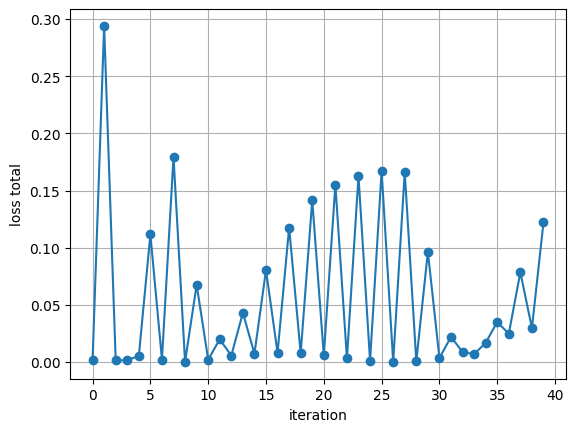

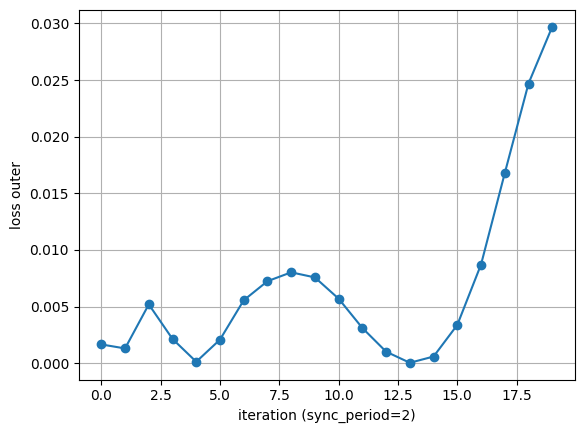

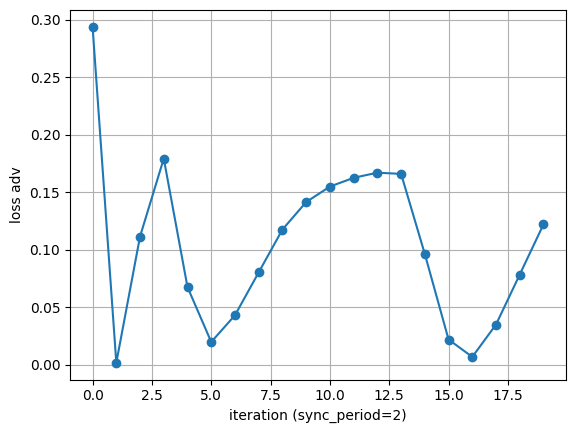

In [ ]:
f, ax = plt.subplots()
ax.plot(values, "-o")
ax.set_xlabel("iteration")
ax.set_ylabel("loss total")
ax.grid()

f, ax = plt.subplots()
filtered_values_outer = [val for i, val in enumerate(values) if i % sync_period == 0]
ax.plot(filtered_values_outer, "-o")
ax.set_xlabel(f"iteration (sync_period={sync_period})")
ax.set_ylabel("loss outer")
ax.grid()

f, ax = plt.subplots()
filtered_values_adv = [val for i, val in enumerate(values) if i % sync_period != 0]
ax.plot(filtered_values_adv, "-o")
ax.set_xlabel(f"iteration (sync_period={sync_period})")
ax.set_ylabel("loss adv")
ax.grid()

Select the iter which has less adversarial loss and its next outer iter number. As SAM is first order approximation, it is better to examine other minima.

In [ ]:
min_adv = min(filtered_values_adv)
adv_iter_num = values.index(min_adv)
iter_num = int(np.round(adv_iter_num / sync_period) * sync_period - (sync_period - 1)) - 1
iter_num = 12  # trying for different minima
print(f"Robust iteration: {iter_num}")

Robust iteration: 12


We take simulation data and calculate performance metrics (power, IL, split ratio, etc.).

In [ ]:
def get_data_vs_sim(batch_data: dict[str, td.SimulationData]) -> dict[str, dict]:
    """Returns a dictionary of results from a batch of simulations."""
    data = {}
    for name, simdata in batch_data.items():
        cross = np.abs(simdata["cross"].amps.sel(mode_index=0, direction="+").values) ** 2
        thru = np.abs(simdata["thru"].amps.sel(mode_index=0, direction="+").values) ** 2
        T = cross + thru
        IL_dB = -10 * np.log10(T)
        splitratios = thru / cross
        wl = td.C_0 / simdata["thru"].amps.sel(mode_index=0, direction="+").f.values

        data[name] = {
            "cross": cross,
            "thru": thru,
            "IL_dB": IL_dB,
            "splitratio": splitratios,
            "wl": wl,
        }
    return data

In [ ]:
eval_bandwidth = 0.1
eval_num_freqs = 101
starting_design = design0

params_at_iter = history[iter_num]["params"]
sim_start_port1 = make_simulation(
    starting_design, port="port1", eval_bandwidth=eval_bandwidth, eval_num_freqs=eval_num_freqs
)
sim_start_port2 = make_simulation(
    starting_design, port="port2", eval_bandwidth=eval_bandwidth, eval_num_freqs=eval_num_freqs
)

design_at_iter = array_to_design(np.array(params_at_iter), (num_pts, num_pts, num_pts, num_pts))
sim_iter_port1 = make_simulation(
    design_at_iter, port="port1", eval_bandwidth=eval_bandwidth, eval_num_freqs=eval_num_freqs
)
sim_iter_port2 = make_simulation(
    design_at_iter, port="port2", eval_bandwidth=eval_bandwidth, eval_num_freqs=eval_num_freqs
)

sims = {
    "port1_at_start": sim_start_port1,
    "port2_at_start": sim_start_port2,
    "port1_at_iter": sim_iter_port1,
    "port2_at_iter": sim_iter_port2,
}

batch_data = td.web.run_async(sims, path_dir="data")
analysis = get_data_vs_sim(batch_data)

Output()

18:34:37 EDT Started working on Batch containing 4 tasks.

18:34:41 EDT Maximum FlexCredit cost: 0.285 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

18:34:42 EDT Batch complete.

Output()

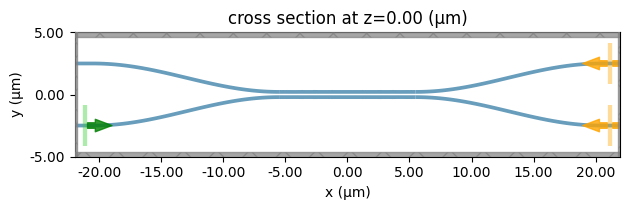

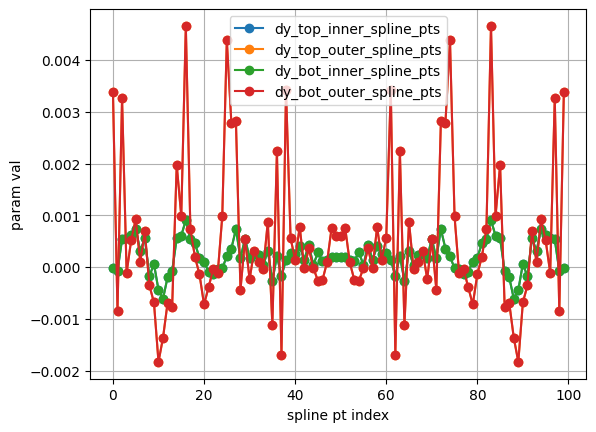

In [ ]:
sims_port1 = {
    "nominal": make_simulation(
        design_at_iter, port="port1", eval_bandwidth=eval_bandwidth, eval_num_freqs=eval_num_freqs
    )
}
ax = sims_port1["nominal"].plot(z=0)

f, ax = plt.subplots()
for key, val in design_at_iter.items():
    ax.plot(val, "-o", label=key)
ax.set_xlabel("spline pt index")
ax.set_ylabel("param val")
ax.legend()
ax.grid()

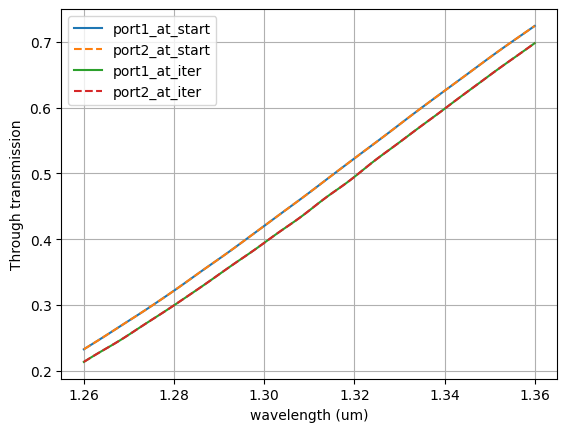

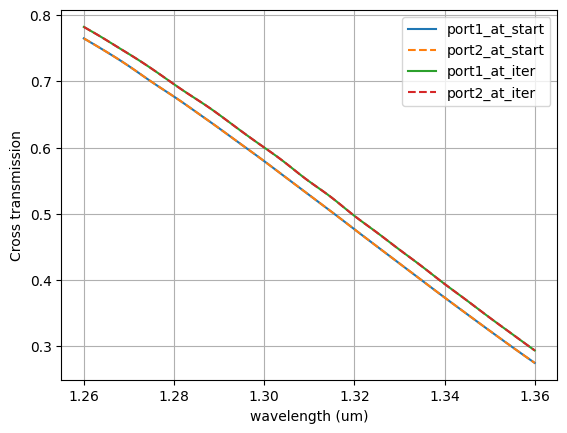

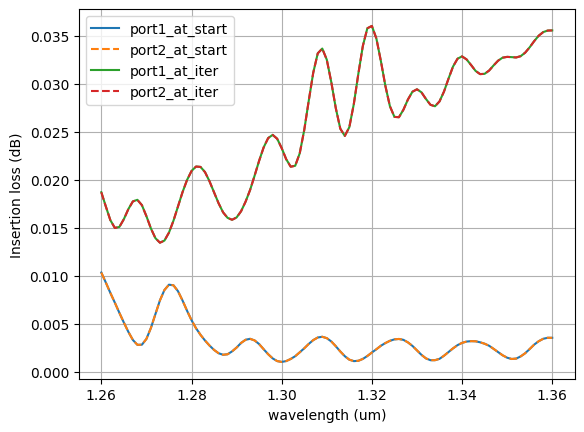

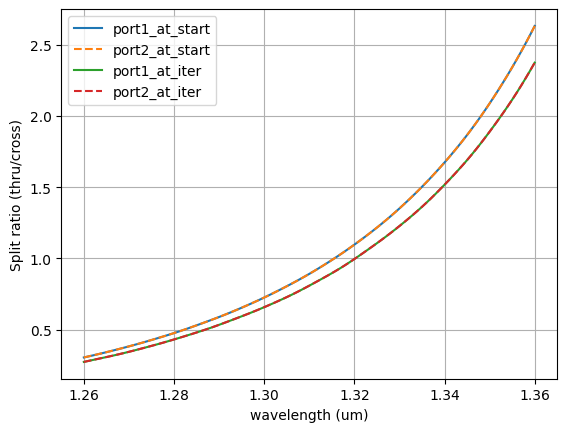

In [ ]:
f, ax = plt.subplots()
for key, val in analysis.items():
    style = "--" if "port2" in key else "-"
    ax.plot(val["wl"], val["thru"], linestyle=style, label=key)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Through transmission")
ax.grid(True)
ax.legend()

f, ax = plt.subplots()
for key, val in analysis.items():
    style = "--" if "port2" in key else "-"
    ax.plot(val["wl"], val["cross"], linestyle=style, label=key)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Cross transmission")
ax.grid(True)
ax.legend()

f, ax = plt.subplots()
for key, val in analysis.items():
    style = "--" if "port2" in key else "-"
    ax.plot(val["wl"], val["IL_dB"], linestyle=style, label=key)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Insertion loss (dB)")
ax.grid(True)
ax.legend()

f, ax = plt.subplots()
for key, val in analysis.items():
    style = "--" if "port2" in key else "-"
    ax.plot(val["wl"], val["splitratio"], linestyle=style, label=key)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Split ratio (thru/cross)")
ax.grid(True)
ax.legend()

plt.show()

We simulate for manufacturing corners that is variability in width perturbation to check design robustness.

In [ ]:
def create_corner_sims(
    design_dict_start: dict,
    design_dict_iter: dict,
    include_nominal: bool = True,
    ports: tuple[str, ...] = ("port1", "port2"),
    n_samples: int = 2,
    dy_range: tuple[float, float] = (-0.01, 0.01),
    rng: np.random.Generator | None = None,
):
    """
    Build a dict of Tidy3D simulations containing one nominal design plus
    `n_samples` random perturbations.

    """
    if rng is None:
        rng = np.random.default_rng(rng_seed)

    sims_start: dict[str, td.Simulation] = {}
    sims_iter: dict[str, td.Simulation] = {}

    # Nominal
    if include_nominal:
        for port in ports:
            sims_start[f"nominal_{port}"] = make_simulation(
                design_dict_start,
                port=port,
                eval_bandwidth=eval_bandwidth,
                eval_num_freqs=eval_num_freqs,
            )
            sims_iter[f"nominal_{port}"] = make_simulation(
                design_dict_iter,
                port=port,
                eval_bandwidth=eval_bandwidth,
                eval_num_freqs=eval_num_freqs,
            )

    #  Random samples
    for i in range(n_samples):
        # Randomise the geometry
        design_sample_start = copy.deepcopy(design_dict_start)
        design_sample_iter = copy.deepcopy(design_dict_iter)
        for k, v in design_sample_start.items():
            if k.startswith("dy_") and isinstance(v, np.ndarray):
                random_perturbation = rng.uniform(dy_range[0], dy_range[1], size=v.shape)
                design_sample_start[k] += random_perturbation
                design_sample_iter[k] += random_perturbation

        #  Build simulations for every requested port
        label = f"sample{i:02d}"
        for port in ports:
            sims_start[f"{label}_{port}"] = make_simulation(
                design_sample_start,
                port=port,
                eval_bandwidth=eval_bandwidth,
                eval_num_freqs=eval_num_freqs,
            )
            sims_iter[f"{label}_{port}"] = make_simulation(
                design_sample_iter,
                port=port,
                eval_bandwidth=eval_bandwidth,
                eval_num_freqs=eval_num_freqs,
            )

    return sims_start, sims_iter

Combine current‑iteration and starting designs under ±3σ coupling region width perturbations. Where σ is adv_rate/3 nm.


In [ ]:
corner_sims_start, corner_sims_iter = create_corner_sims(
    design_dict_start=starting_design,
    design_dict_iter=design_at_iter,
    include_nominal=True,
    n_samples=10,
    dy_range=(-adv_rate, adv_rate),
)

combined_corner_sims = {}
for name, sim in corner_sims_iter.items():
    combined_corner_sims[f"iter_{name}"] = sim
for name, sim in corner_sims_start.items():
    combined_corner_sims[f"start_{name}"] = sim

print(f"Running {len(combined_corner_sims)} corner simulations...")

batch_data = td.web.run_async(combined_corner_sims, path_dir="data_corners")
print("Simulations complete. Processing results...")

results_corner = get_data_vs_sim(batch_data)
print("Results processed.")

Output()

Running 44 corner simulations...


18:35:02 EDT Started working on Batch containing 44 tasks.

18:35:37 EDT Maximum FlexCredit cost: 3.116 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

18:35:57 EDT Batch complete.

Output()

Simulations complete. Processing results...
Results processed.


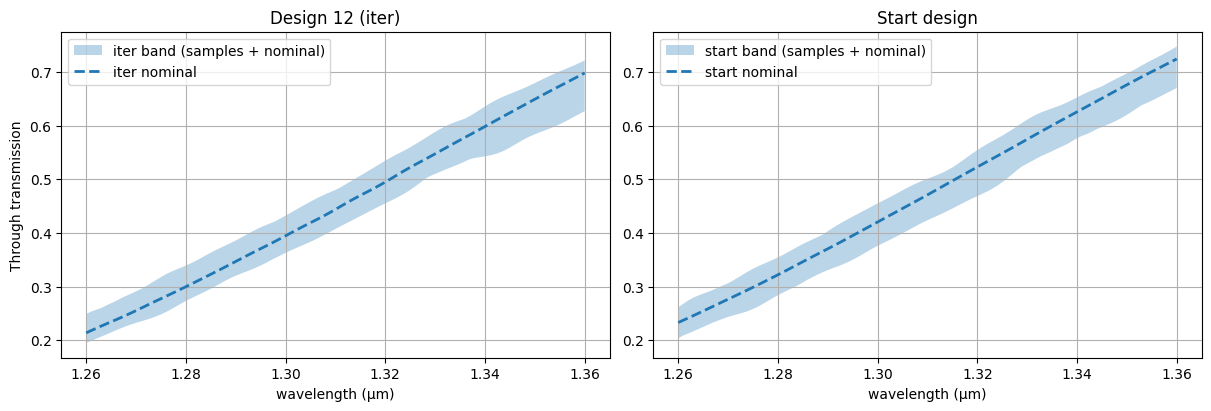

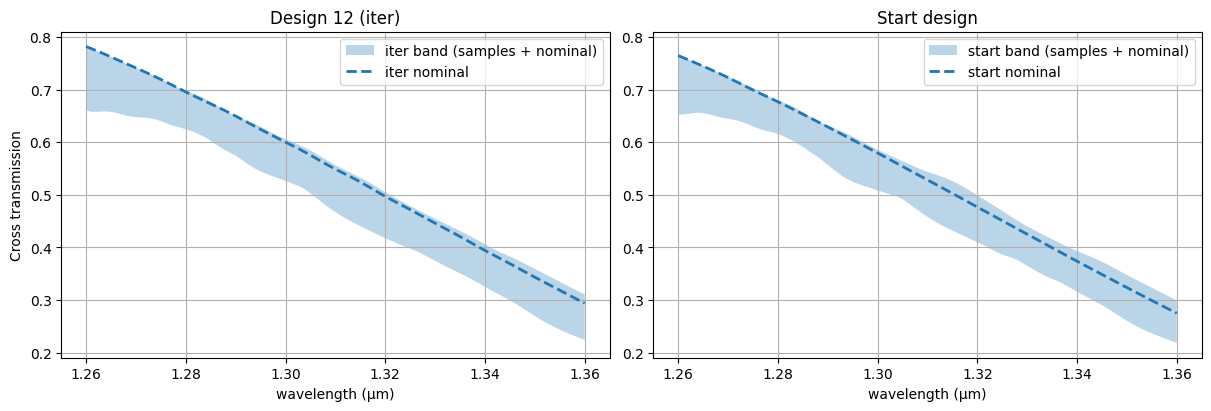

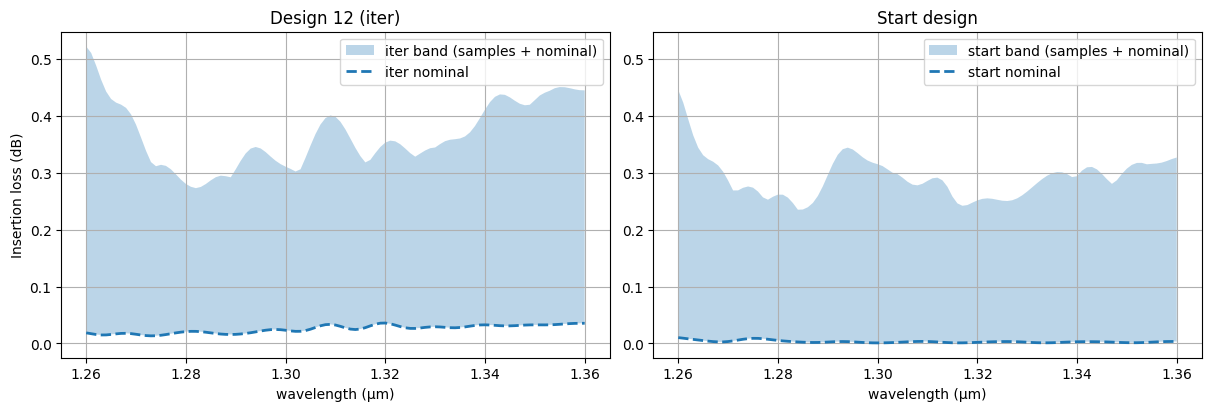

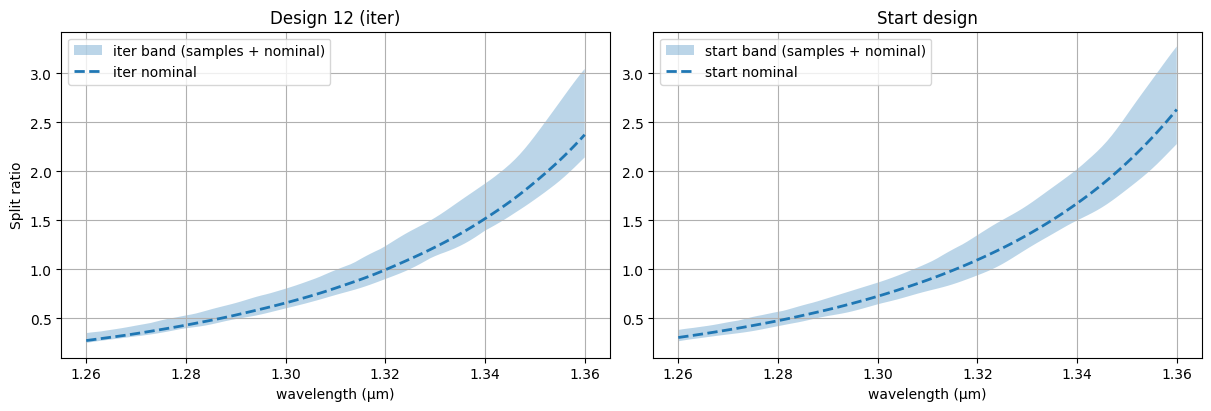

In [ ]:
def plot_bands(
    results: dict,
    prefix1: str,
    prefix2: str,
    metric: str,
    xlabel: str,
    ylabel: str,
    title1: str,
    title2: str | None = None,
):
    """
    Plot the results of the simulations.
    """
    wl = next(iter(results.values()))["wl"]

    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 4), constrained_layout=True)

    for ax, prefix, ttl in zip(
        (ax1, ax2), (prefix1, prefix2), (title1, title2 or prefix2.capitalize())
    ):
        # All keys for this design
        keys_prefixed = [k for k in results if k.startswith(prefix + "_")]

        # Split out the nominal vs. the random samples
        nominal = [k for k in keys_prefixed if "_nominal" in k]
        samples = [k for k in keys_prefixed if "_sample" in k]

        # Build the band across *all* samples + nominal
        band_keys = samples + nominal
        data = np.stack([results[k][metric] for k in band_keys], axis=0)
        y_min, y_max = data.min(axis=0), data.max(axis=0)
        ax.fill_between(wl, y_min, y_max, alpha=0.3, label=f"{prefix} band (samples + nominal)")

        # Overplot the nominal curve
        if nominal:
            nom = nominal[0]
            ax.plot(wl, results[nom][metric], "--", linewidth=2, label=f"{prefix} nominal")

        ax.set_title(ttl)
        ax.set_xlabel(xlabel)
        ax.grid(True)
        ax.legend()

    ax1.set_ylabel(ylabel)
    ax2.tick_params(axis="y", labelleft=True)
    ax2.spines["left"].set_visible(True)

    return fig, (ax1, ax2)


fig, (ax_iter, ax_start) = plot_bands(
    results_corner,
    prefix1="iter",
    prefix2="start",
    metric="thru",
    xlabel="wavelength (µm)",
    ylabel="Through transmission",
    title1=f"Design {iter_num} (iter)",
    title2="Start design",
)

fig, (ax_iter, ax_start) = plot_bands(
    results_corner,
    prefix1="iter",
    prefix2="start",
    metric="cross",
    xlabel="wavelength (µm)",
    ylabel="Cross transmission",
    title1=f"Design {iter_num} (iter)",
    title2="Start design",
)

fig, (ax_iter, ax_start) = plot_bands(
    results_corner,
    prefix1="iter",
    prefix2="start",
    metric="IL_dB",
    xlabel="wavelength (µm)",
    ylabel="Insertion loss (dB)",
    title1=f"Design {iter_num} (iter)",
    title2="Start design",
)

fig, (ax_iter, ax_start) = plot_bands(
    results_corner,
    prefix1="iter",
    prefix2="start",
    metric="splitratio",
    xlabel="wavelength (µm)",
    ylabel="Split ratio",
    title1=f"Design {iter_num} (iter)",
    title2="Start design",
)

From the band plot of splitratio, we observe for SAM the band is reduced compared to the initial design indicating reduced variations with respect to boundary perturbations.

Plot the difference between the max and min values of the band.

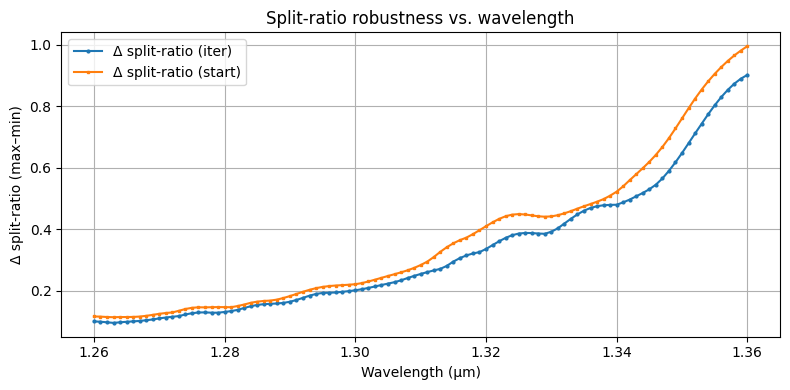

In [ ]:
def band_spread(results: dict, prefix: str, metric: str) -> np.ndarray:
    """
    For a given `prefix` ('iter' or 'start') and `metric`
    ('splitratio', 'thru', …) return the (max-min) envelope
    across *all* nominal + sample simulations.
    """
    wanted = [
        k
        for k in results
        if k.startswith(prefix + "_")  # iter_… or start_…
        and ("_sample" in k or "_nominal" in k)  # keep only band members
    ]
    if not wanted:
        raise ValueError(f"No simulations found for prefix='{prefix}'")

    data = np.stack([results[k][metric] for k in wanted], axis=0)
    return np.ptp(data, axis=0)


wl = next(iter(results_corner.values()))["wl"]
delta_iter = band_spread(results_corner, "iter", "splitratio")
delta_start = band_spread(results_corner, "start", "splitratio")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wl, delta_iter, "-o", label="Δ split-ratio (iter)", markersize=2)
ax.plot(wl, delta_start, "-s", label="Δ split-ratio (start)", markersize=2)

ax.set(
    xlabel="Wavelength (µm)",
    ylabel="Δ split-ratio (max–min)",
    title="Split-ratio robustness vs. wavelength",
)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()